<a href="https://www.kaggle.com/code/prathvibhatti/aeroxai?scriptVersionId=295832923" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [56]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================
print("Installing dependencies...")

!pip install -q ultralytics pandas matplotlib seaborn

print("Installation complete!")


Installing dependencies...
Installation complete!


In [57]:
# ============================================================
# IMPORT REQUIRED MODULES
# ============================================================
import os
import glob
import shutil
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from ultralytics import YOLO

print("All modules imported successfully.")


All modules imported successfully.


In [58]:
# ============================================================
# DEFINE DATASET LOCATIONS
# ============================================================

BASE = "/kaggle/input/visdrone-dataset/VisDrone_Dataset"

TRAIN_IMG = os.path.join(BASE, "VisDrone2019-DET-train", "images")
TRAIN_LBL = os.path.join(BASE, "VisDrone2019-DET-train", "labels")

VAL_IMG = os.path.join(BASE, "VisDrone2019-DET-val", "images")
VAL_LBL = os.path.join(BASE, "VisDrone2019-DET-val", "labels")

print("Dataset paths configured.")

print("Training images :", len(os.listdir(TRAIN_IMG)))
print("Training labels :", len(os.listdir(TRAIN_LBL)))
print("Validation images :", len(os.listdir(VAL_IMG)))
print("Validation labels :", len(os.listdir(VAL_LBL)))


Dataset paths configured.
Training images : 6471
Training labels : 6471
Validation images : 548
Validation labels : 548


In [60]:
# ============================================================
# PREPARE WORKING DATA STRUCTURE
# ============================================================

print("Creating YOLO working directories...")

!mkdir -p /kaggle/working/visdrone_yolo/train/images
!mkdir -p /kaggle/working/visdrone_yolo/train/labels
!mkdir -p /kaggle/working/visdrone_yolo/val/images
!mkdir -p /kaggle/working/visdrone_yolo/val/labels

print("Directory structure created.")


Creating YOLO working directories...
Directory structure created.


In [61]:
# ============================================================
# COPY DATA INTO WORKING DIRECTORY
# ============================================================

print("Copying training data...")

for f in os.listdir(TRAIN_IMG):
    if f.endswith(".jpg"):
        shutil.copy(os.path.join(TRAIN_IMG, f), "/kaggle/working/visdrone_yolo/train/images/")

for f in os.listdir(TRAIN_LBL):
    if f.endswith(".txt"):
        shutil.copy(os.path.join(TRAIN_LBL, f), "/kaggle/working/visdrone_yolo/train/labels/")

print("Training data copied.")

print("Copying validation data...")

for f in os.listdir(VAL_IMG):
    if f.endswith(".jpg"):
        shutil.copy(os.path.join(VAL_IMG, f), "/kaggle/working/visdrone_yolo/val/images/")

for f in os.listdir(VAL_LBL):
    if f.endswith(".txt"):
        shutil.copy(os.path.join(VAL_LBL, f), "/kaggle/working/visdrone_yolo/val/labels/")

print("Validation data copied successfully.")


Copying training data...
Training data copied.
Copying validation data...
Validation data copied successfully.


In [62]:
# ============================================================
# CREATE YOLO CONFIG FILE
# ============================================================

yaml = """
train: /kaggle/working/visdrone_yolo/train
val: /kaggle/working/visdrone_yolo/val

nc: 10

names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
"""

with open("visdrone.yaml", "w") as f:
    f.write(yaml)

print("YOLO YAML configuration saved.")


YOLO YAML configuration saved.


In [63]:
# ============================================================
# TRAIN YOLOv8 MODEL
# ============================================================

print("Initializing YOLO model...")

model = YOLO("yolov8n.pt")

print("Starting training...")

model.train(
    data="visdrone.yaml",
    epochs=3,
    imgsz=320,
    batch=2,
    workers=1
)

print("Training finished.")


Initializing YOLO model...
Starting training...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

In [64]:
# ============================================================
# LOAD BEST TRAINED MODEL
# ============================================================

paths = glob.glob("/kaggle/working/runs/detect/**/best.pt", recursive=True)

trained = YOLO(paths[0])

print("Loaded trained model from:", paths[0])


Loaded trained model from: /kaggle/working/runs/detect/train/weights/best.pt


In [65]:
# ============================================================
# RUN DETECTION AND SAVE RESULTS
# ============================================================

OUTPUT_DIR = "/kaggle/working/final_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

samples = os.listdir("/kaggle/working/visdrone_yolo/val/images")[:10]

for img in samples:

    path = f"/kaggle/working/visdrone_yolo/val/images/{img}"

    results = trained.predict(path, conf=0.25, save=True)

    pred = glob.glob(f"runs/detect/predict*/{img}")

    if pred:
        shutil.copy(pred[0], OUTPUT_DIR)

print("Detection images saved for XAI analysis.")



image 1/1 /kaggle/working/visdrone_yolo/val/images/0000280_03001_d_0000627.jpg: 192x320 1 pedestrian, 10 cars, 6.8ms
Speed: 0.8ms preprocess, 6.8ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)
Results saved to /kaggle/working/runs/detect/predict2

image 1/1 /kaggle/working/visdrone_yolo/val/images/0000291_04001_d_0000888.jpg: 192x320 5 pedestrians, 29 cars, 5.5ms
Speed: 0.6ms preprocess, 5.5ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)
Results saved to /kaggle/working/runs/detect/predict2

image 1/1 /kaggle/working/visdrone_yolo/val/images/0000271_06401_d_0000404.jpg: 192x320 56 cars, 5.6ms
Speed: 0.6ms preprocess, 5.6ms inference, 1.2ms postprocess per image at shape (1, 3, 192, 320)
Results saved to /kaggle/working/runs/detect/predict2

image 1/1 /kaggle/working/visdrone_yolo/val/images/0000335_02353_d_0000055.jpg: 192x320 13 cars, 6.1ms
Speed: 0.7ms preprocess, 6.1ms inference, 1.2ms postprocess per image at shape (1, 3, 192, 320)
Results s

In [66]:
# ============================================================
# CREATE STRUCTURED DETECTION DATASET
# ============================================================

records = []

for img in os.listdir(OUTPUT_DIR):

    path = os.path.join(OUTPUT_DIR, img)

    results = trained.predict(path, conf=0.25)

    for r in results:
        if r.boxes is None:
            continue

        for box in r.boxes:

            records.append({
                "image": img,
                "class": trained.names[int(box.cls)],
                "confidence": float(box.conf)
            })

df = pd.DataFrame(records)

print("Structured explainability dataset created.")
df.head()



image 1/1 /kaggle/working/final_outputs/0000280_03001_d_0000627.jpg: 192x320 3 pedestrians, 2 cars, 7.5ms
Speed: 0.9ms preprocess, 7.5ms inference, 1.3ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000291_04001_d_0000888.jpg: 192x320 1 car, 5.7ms
Speed: 0.7ms preprocess, 5.7ms inference, 1.4ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000271_06401_d_0000404.jpg: 192x320 9 cars, 5.7ms
Speed: 0.6ms preprocess, 5.7ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000335_02353_d_0000055.jpg: 192x320 3 cars, 5.8ms
Speed: 0.6ms preprocess, 5.8ms inference, 1.0ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000333_01765_d_0000010.jpg: 192x320 (no detections), 5.5ms
Speed: 0.6ms preprocess, 5.5ms inference, 0.5ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outp

,image,class,confidence
0,0000280_03001_d_0000627.jpg,car,0.693453
1,0000280_03001_d_0000627.jpg,car,0.633720
2,0000280_03001_d_0000627.jpg,pedestrian,0.297378
3,0000280_03001_d_0000627.jpg,pedestrian,0.279200
4,0000280_03001_d_0000627.jpg,pedestrian,0.254118


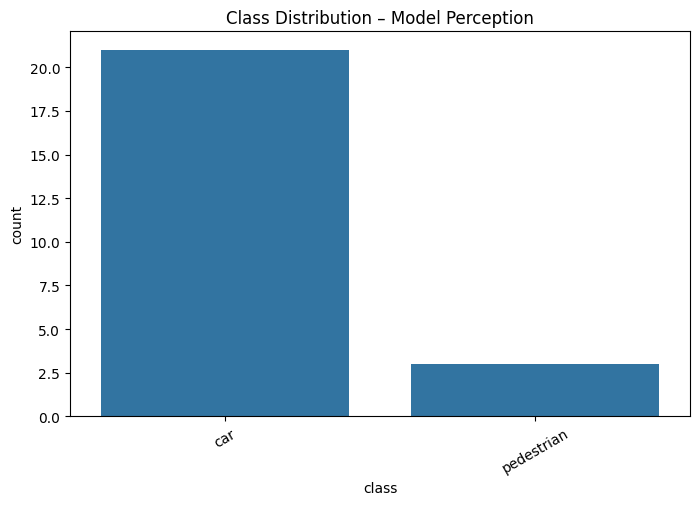

In [68]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="class")
plt.title("Class Distribution – Model Perception")
plt.xticks(rotation=30)
plt.show()


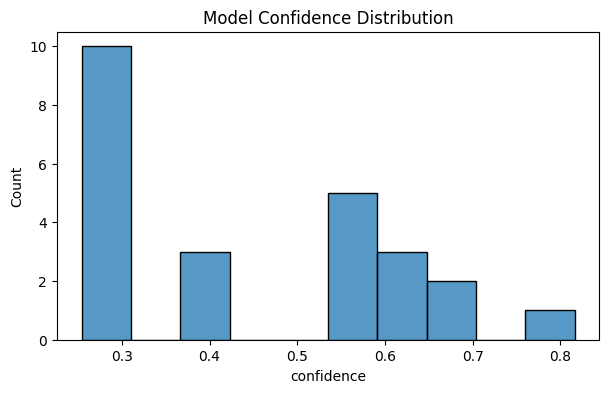

In [69]:
plt.figure(figsize=(7,4))
sns.histplot(df["confidence"], bins=10)
plt.title("Model Confidence Distribution")
plt.show()


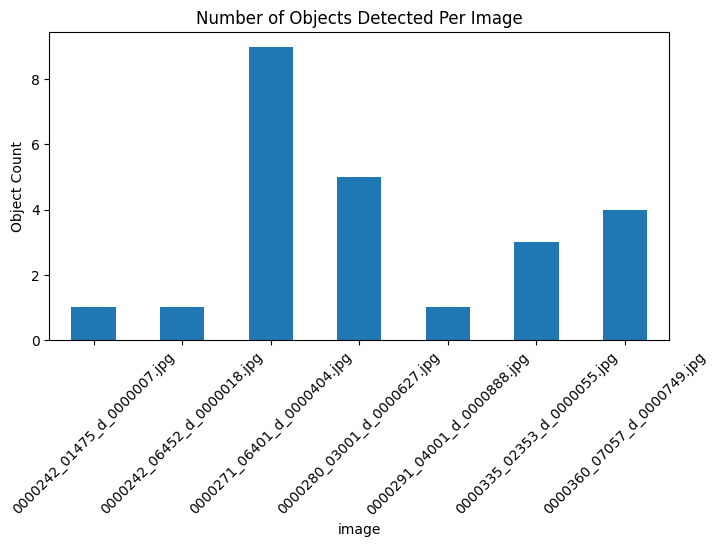

In [70]:
img_complexity = df.groupby("image")["class"].count()

plt.figure(figsize=(8,4))
img_complexity.plot(kind="bar")
plt.title("Number of Objects Detected Per Image")
plt.ylabel("Object Count")
plt.xticks(rotation=45)
plt.show()


In [71]:
# ============================================================
# RULE-BASED NATURAL LANGUAGE EXPLANATIONS
# ============================================================

for img in df["image"].unique():

    sub = df[df["image"] == img]

    print("\nIMAGE:", img)

    if len(sub) == 0:
        print("Model found no recognizable objects.")
        continue

    print("Total objects detected:", len(sub))
    print("Most frequent object:", sub["class"].mode()[0])
    print("Average confidence:", round(sub["confidence"].mean(), 2))



IMAGE: 0000280_03001_d_0000627.jpg
Total objects detected: 5
Most frequent object: pedestrian
Average confidence: 0.43

IMAGE: 0000291_04001_d_0000888.jpg
Total objects detected: 1
Most frequent object: car
Average confidence: 0.39

IMAGE: 0000271_06401_d_0000404.jpg
Total objects detected: 9
Most frequent object: car
Average confidence: 0.52

IMAGE: 0000335_02353_d_0000055.jpg
Total objects detected: 3
Most frequent object: car
Average confidence: 0.38

IMAGE: 0000242_06452_d_0000018.jpg
Total objects detected: 1
Most frequent object: car
Average confidence: 0.27

IMAGE: 0000360_07057_d_0000749.jpg
Total objects detected: 4
Most frequent object: car
Average confidence: 0.4

IMAGE: 0000242_01475_d_0000007.jpg
Total objects detected: 1
Most frequent object: car
Average confidence: 0.61


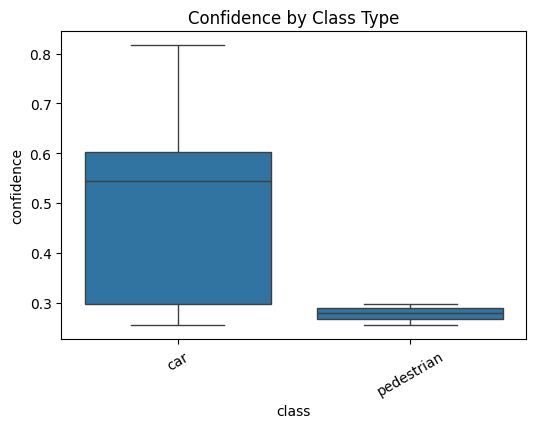

In [72]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="class", y="confidence")
plt.title("Confidence by Class Type")
plt.xticks(rotation=30)
plt.show()


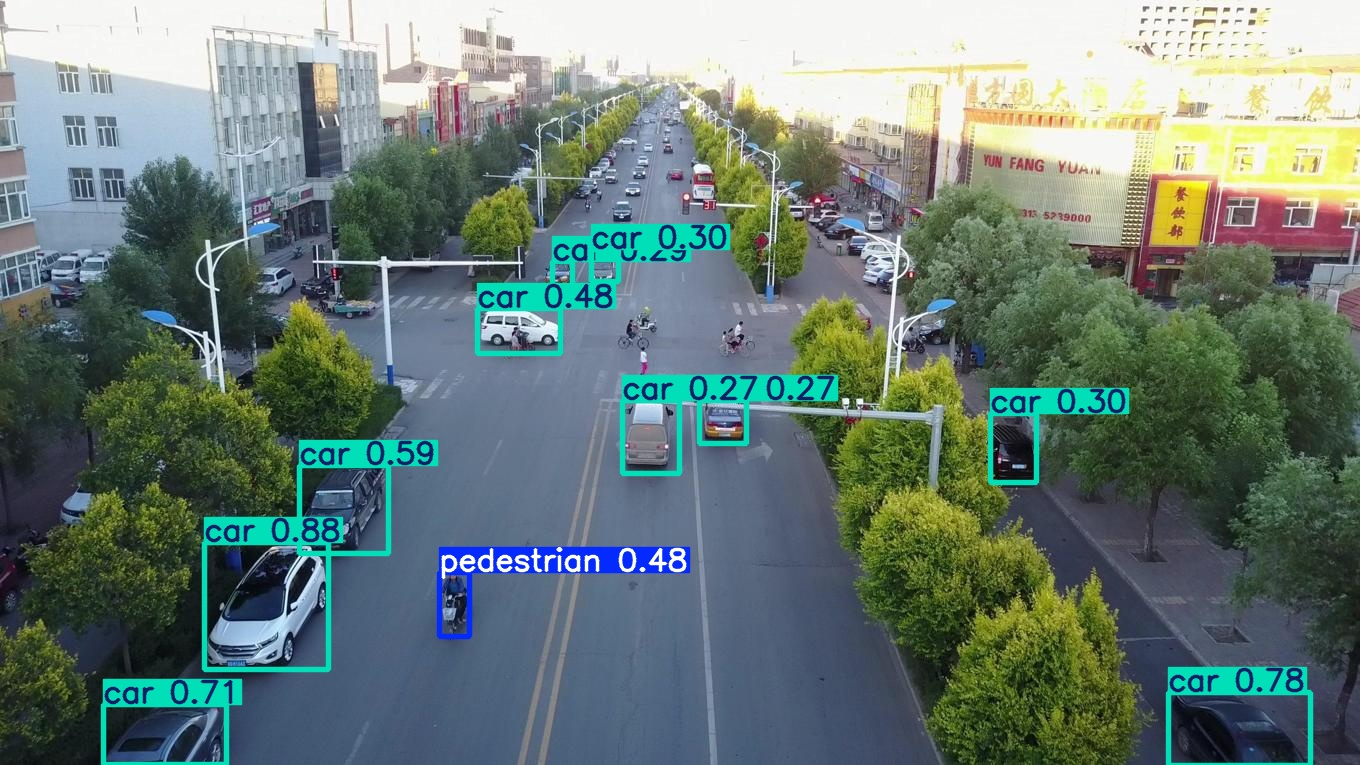

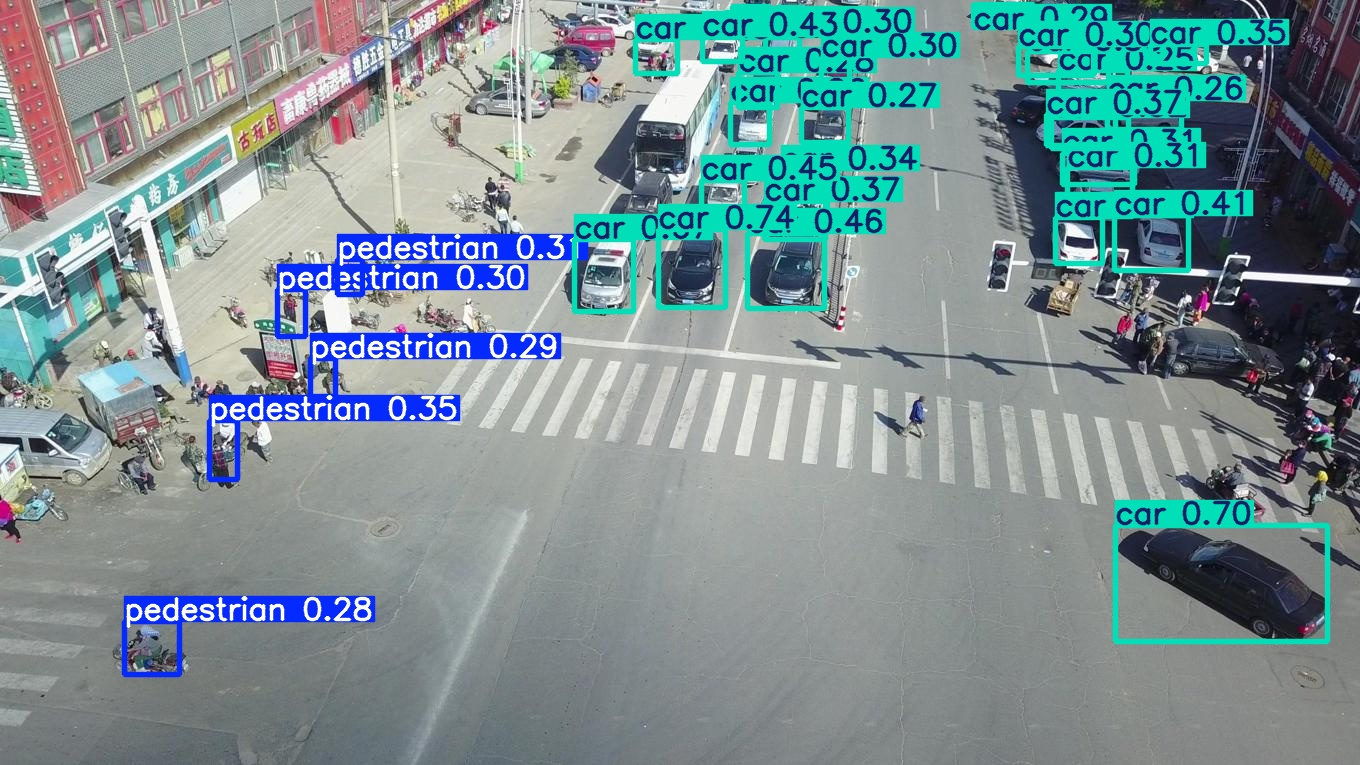

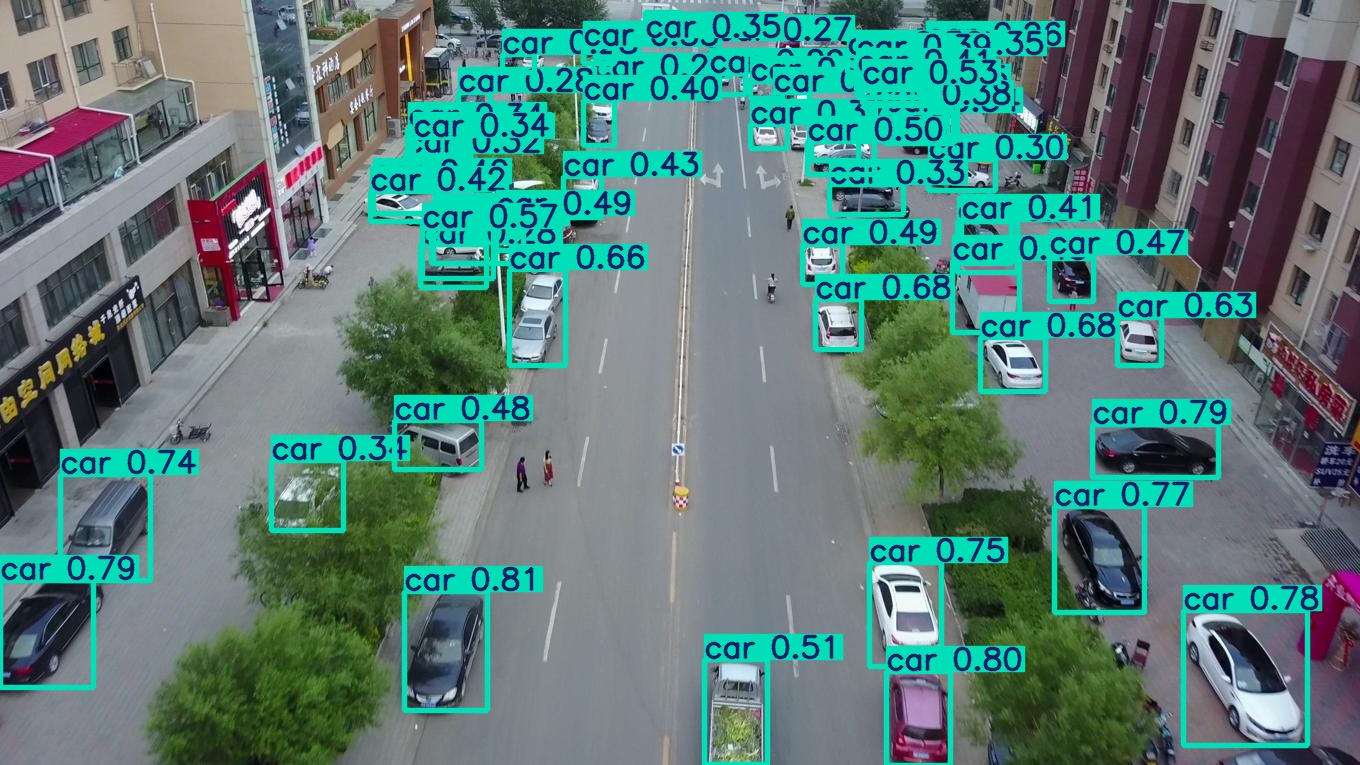

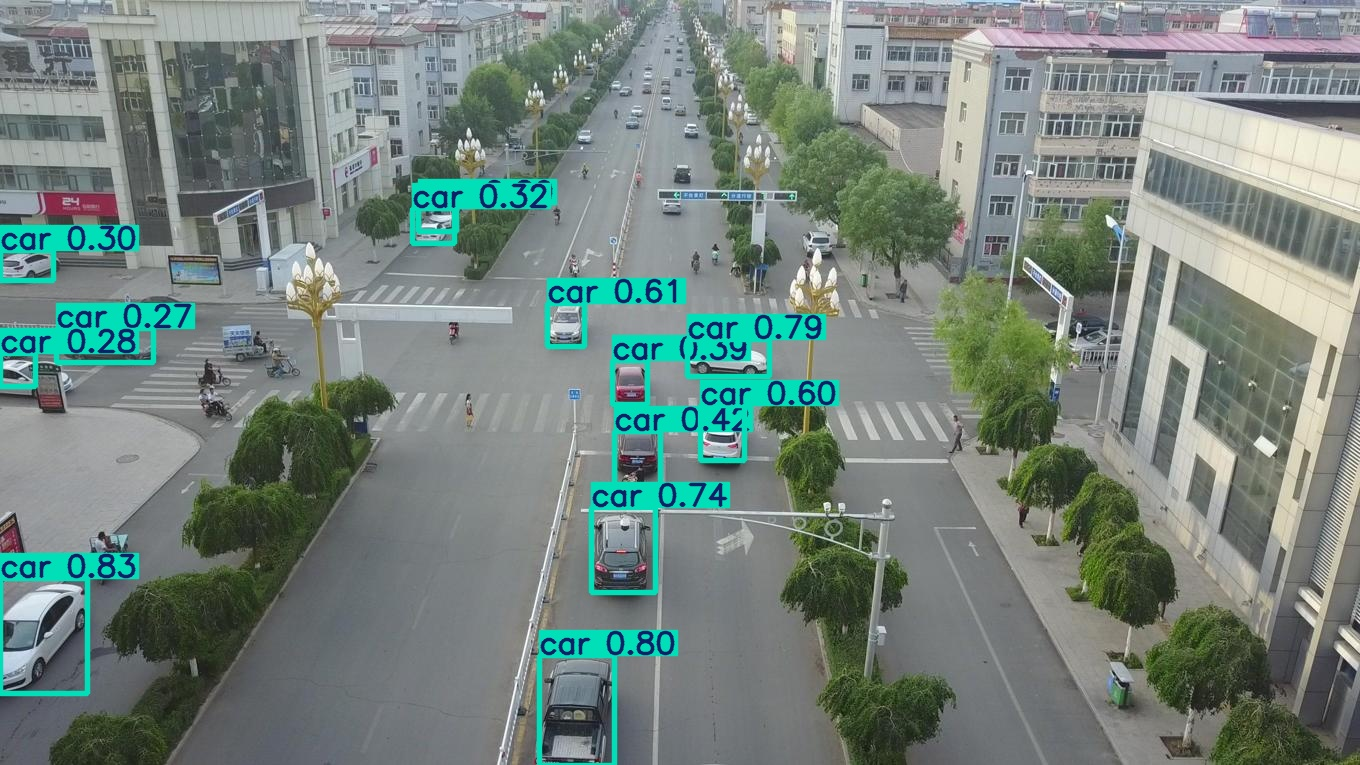

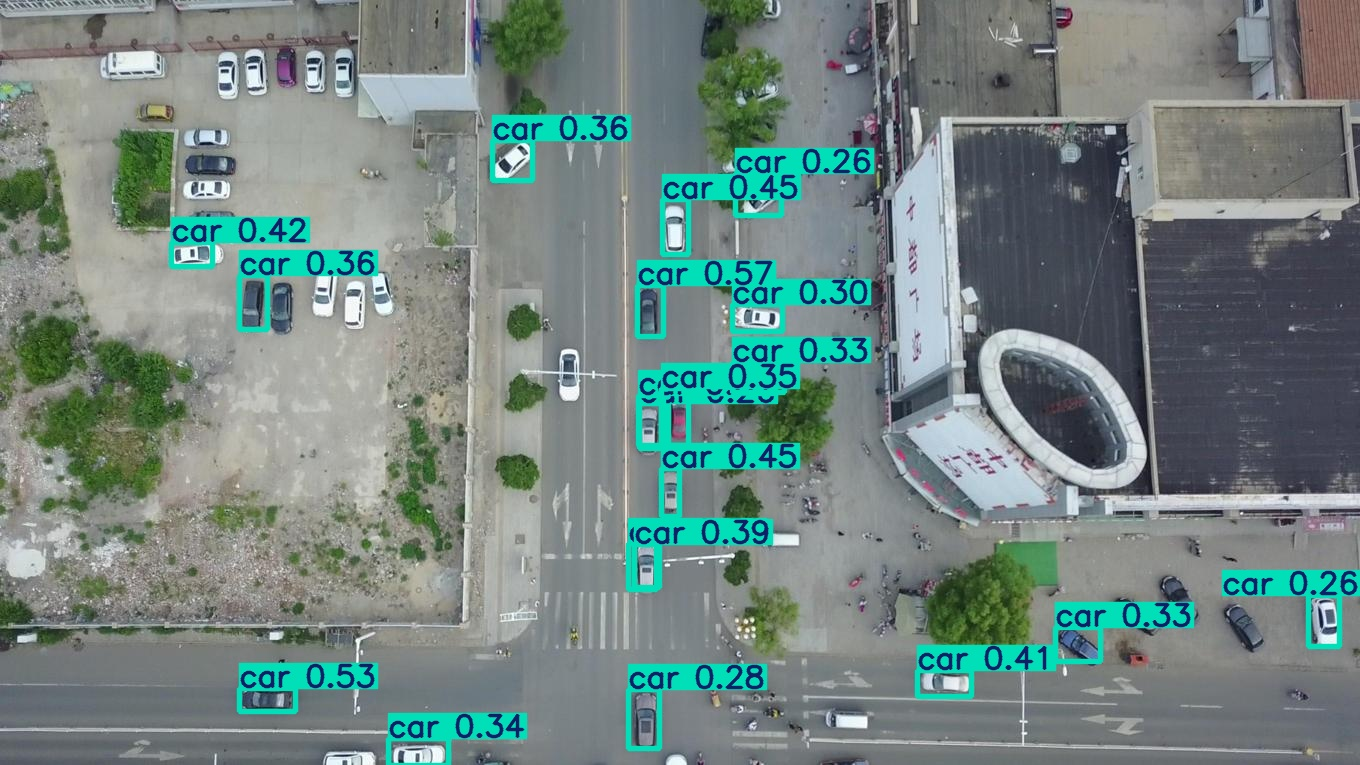

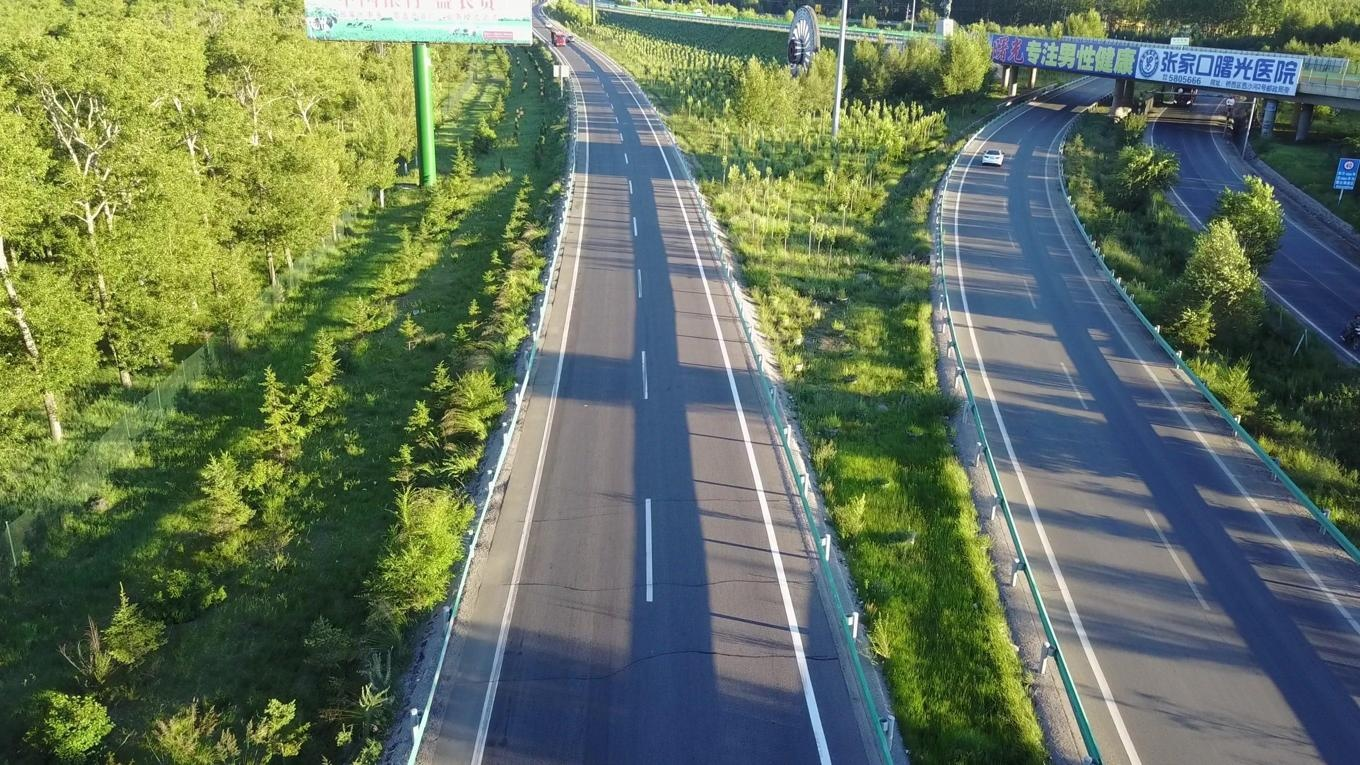

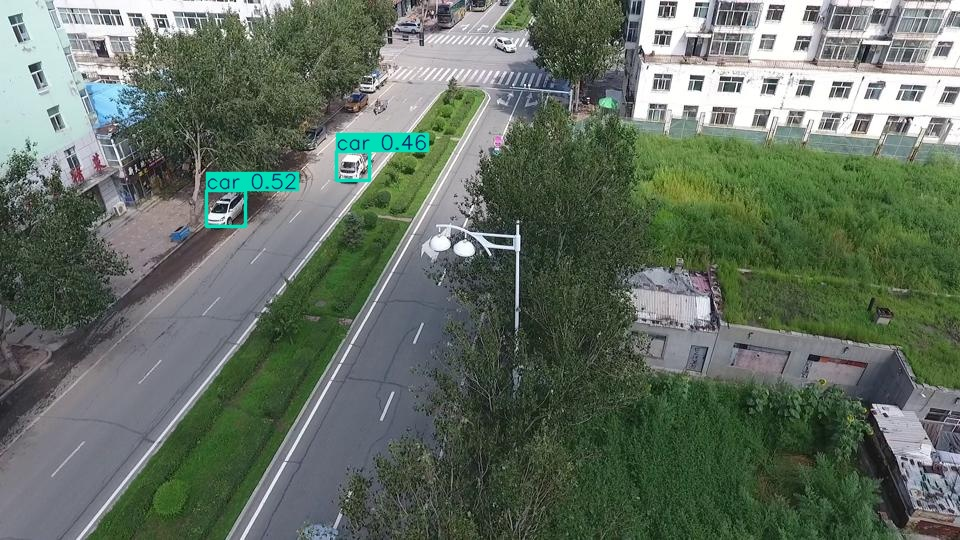

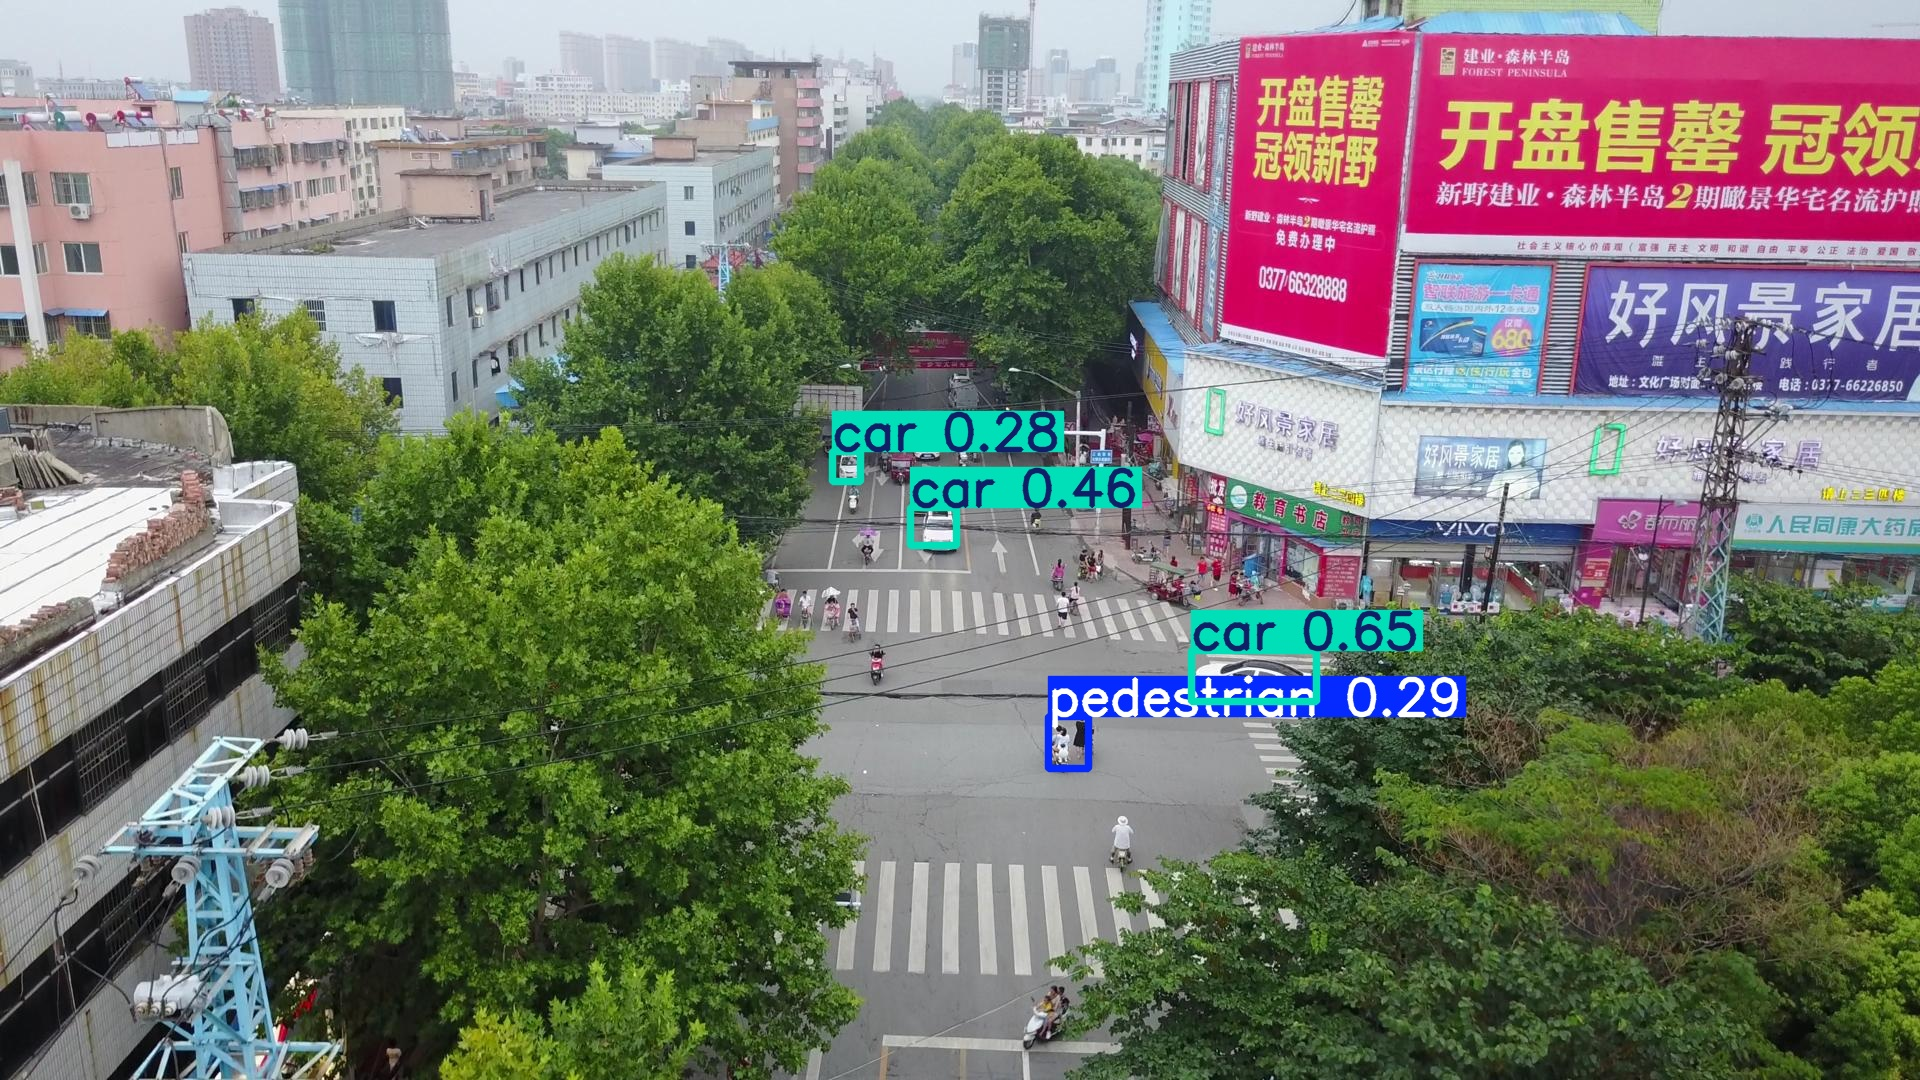

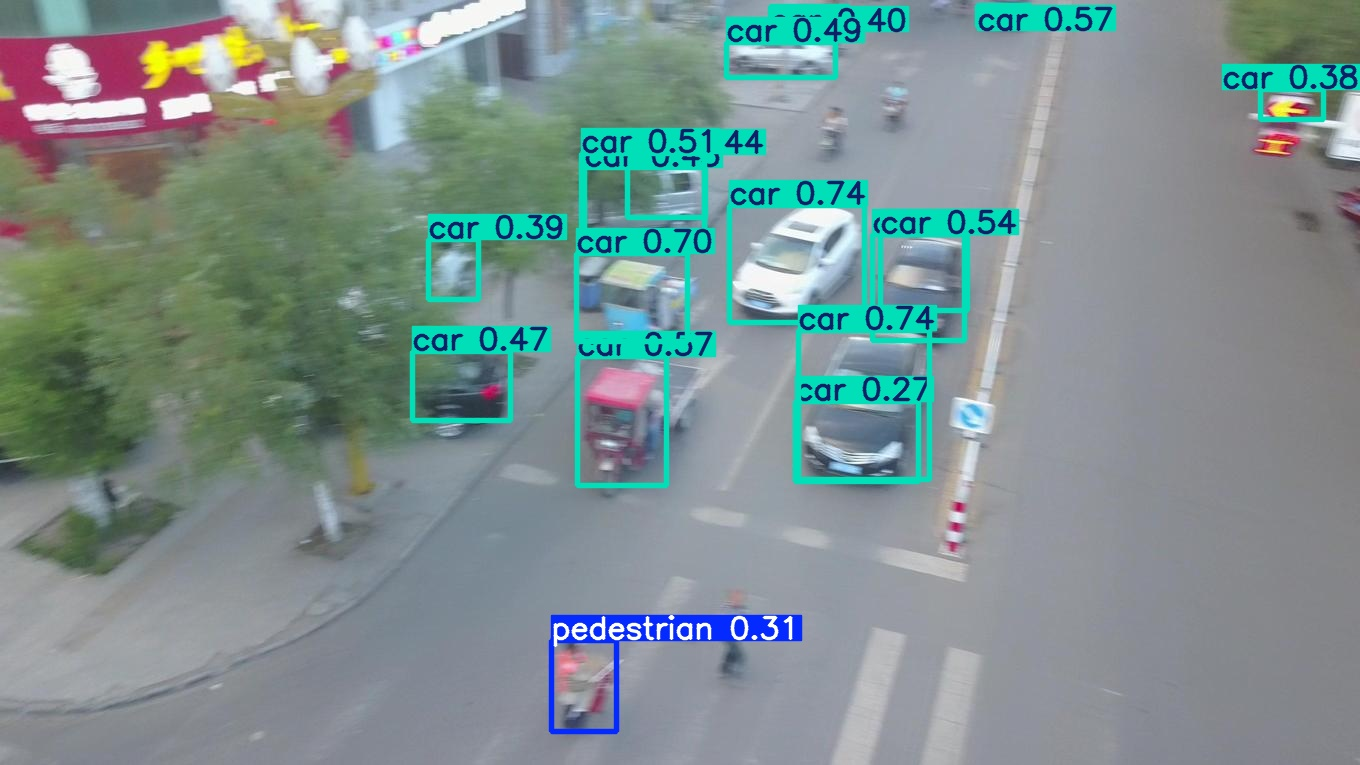

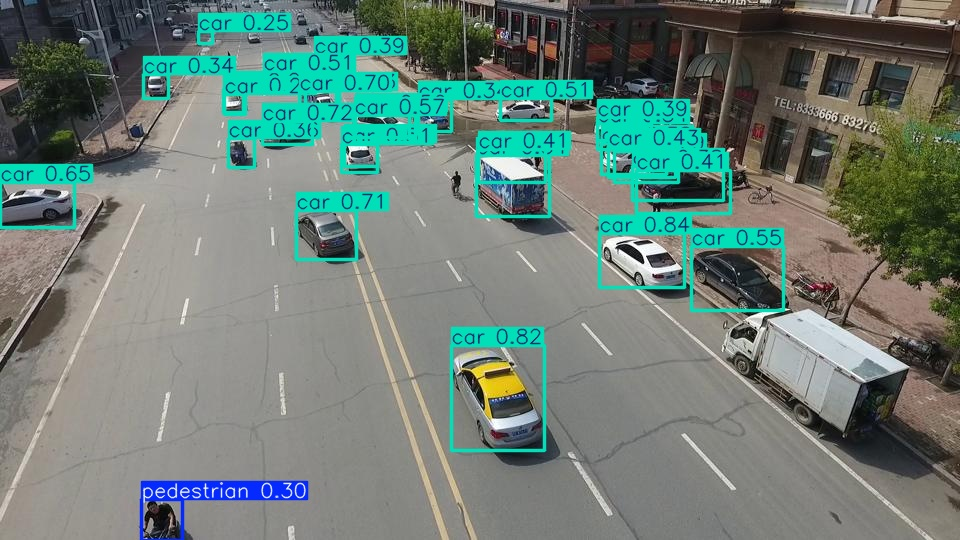

In [73]:
for img in os.listdir(OUTPUT_DIR):
    display(Image(os.path.join(OUTPUT_DIR, img)))


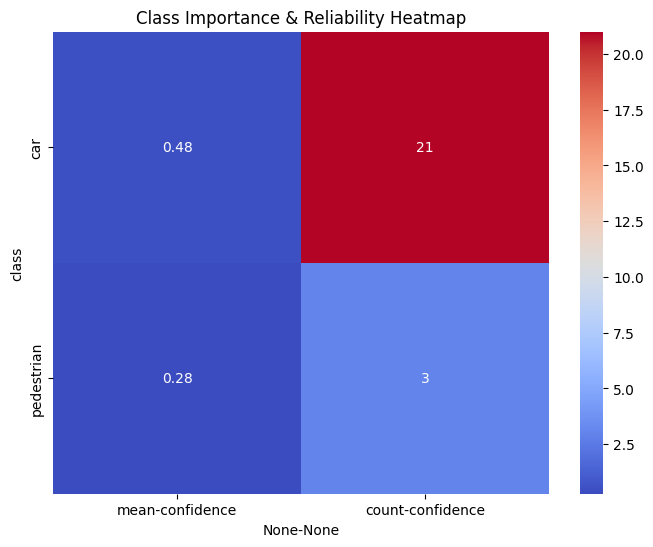

In [75]:
# ============================================================
# ADVANCED XAI-1: CLASS IMPORTANCE HEATMAP
# ============================================================

pivot = df.pivot_table(values="confidence", 
                       index="class", 
                       aggfunc=["mean","count"])

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Class Importance & Reliability Heatmap")
plt.show()


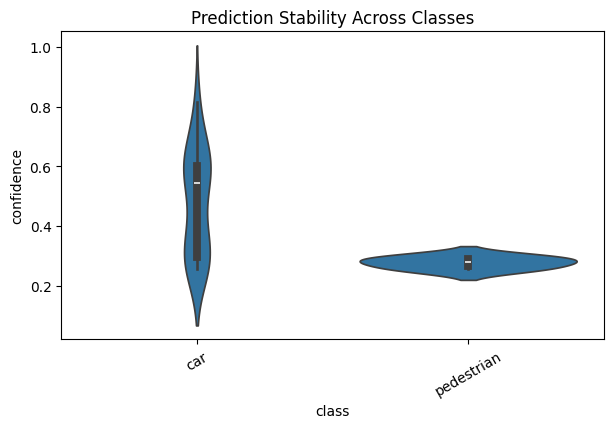

In [76]:
# ============================================================
# ADVANCED XAI-2: STABILITY ANALYSIS
# ============================================================

plt.figure(figsize=(7,4))
sns.violinplot(data=df, x="class", y="confidence")
plt.title("Prediction Stability Across Classes")
plt.xticks(rotation=30)
plt.show()


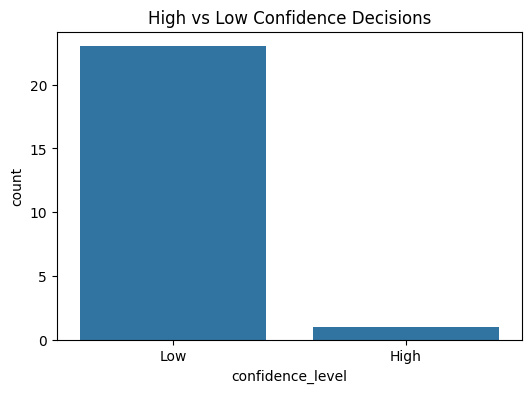

In [78]:
# ============================================================
# ADVANCED XAI-3: LOW VS HIGH CONFIDENCE EXPLANATION
# ============================================================

df["confidence_level"] = df["confidence"].apply(
    lambda x: "High" if x > 0.7 else "Low"
)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="confidence_level")
plt.title("High vs Low Confidence Decisions")
plt.show()


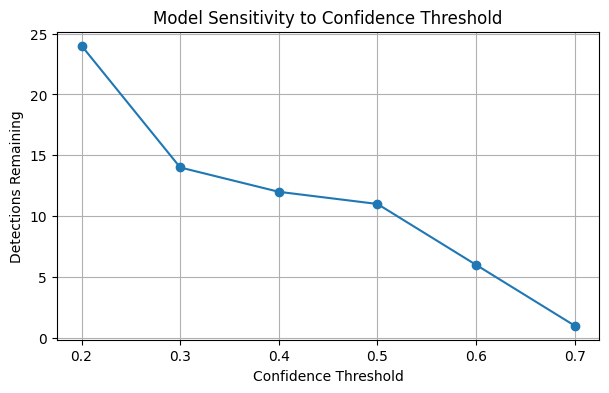

In [80]:
# ============================================================
# ADVANCED XAI-4: SENSITIVITY TO CONFIDENCE THRESHOLD
# ============================================================

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
counts = []

for t in thresholds:
    c = len(df[df["confidence"] >= t])
    counts.append(c)

plt.figure(figsize=(7,4))
plt.plot(thresholds, counts, marker="o")
plt.title("Model Sensitivity to Confidence Threshold")
plt.xlabel("Confidence Threshold")
plt.ylabel("Detections Remaining")
plt.grid()
plt.show()


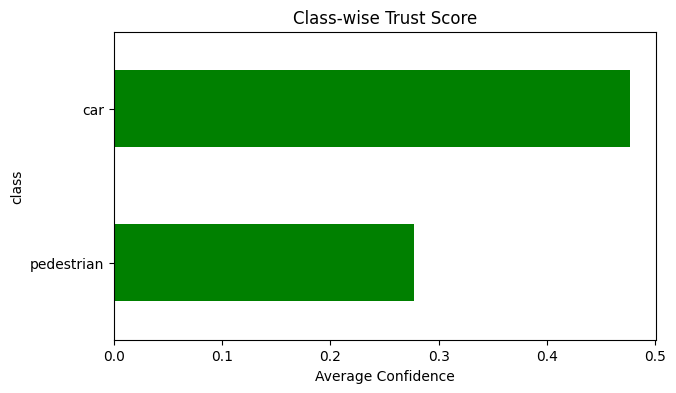

In [81]:
# ============================================================
# ADVANCED XAI-6: CLASS TRUST SCORE
# ============================================================

trust = df.groupby("class")["confidence"].mean().sort_values()

plt.figure(figsize=(7,4))
trust.plot(kind="barh", color="green")
plt.title("Class-wise Trust Score")
plt.xlabel("Average Confidence")
plt.show()


In [82]:
# ============================================================
# ADVANCED XAI-7: OUTLIER PREDICTIONS
# ============================================================

low_conf = df[df["confidence"] < 0.35]

print("Potentially unreliable predictions:\n")
print(low_conf)


Potentially unreliable predictions:

                          image       class  confidence confidence_level
2   0000280_03001_d_0000627.jpg  pedestrian    0.297378              Low
3   0000280_03001_d_0000627.jpg  pedestrian    0.279200              Low
4   0000280_03001_d_0000627.jpg  pedestrian    0.254118              Low
13  0000271_06401_d_0000404.jpg         car    0.260307              Low
14  0000271_06401_d_0000404.jpg         car    0.255554              Low
16  0000335_02353_d_0000055.jpg         car    0.297306              Low
17  0000335_02353_d_0000055.jpg         car    0.283617              Low
18  0000242_06452_d_0000018.jpg         car    0.270149              Low
21  0000360_07057_d_0000749.jpg         car    0.298568              Low
22  0000360_07057_d_0000749.jpg         car    0.287694              Low


In [83]:
# ============================================================
# ADVANCED XAI-8: SURROGATE MODEL INTERPRETATION
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
X = enc.fit_transform(df["class"]).reshape(-1,1)
y = (df["confidence"] > 0.6).astype(int)

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X, y)

print("Surrogate Decision Rules Learned from YOLO Behavior")


Surrogate Decision Rules Learned from YOLO Behavior


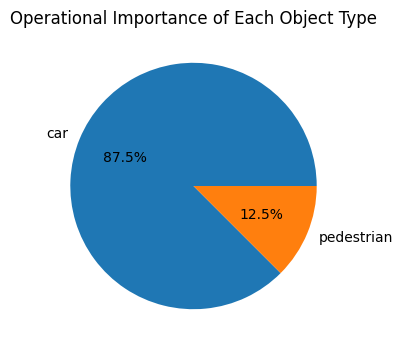

In [84]:
# ============================================================
# ADVANCED XAI-9: BUSINESS IMPACT EXPLANATION
# ============================================================

impact = df.groupby("class").size()

plt.figure(figsize=(7,4))
impact.plot(kind="pie", autopct="%1.1f%%")
plt.title("Operational Importance of Each Object Type")
plt.ylabel("")
plt.show()


In [85]:
# ------------------------------------------------------------
# XAI MODULE: FAILURE ANALYSIS
# ------------------------------------------------------------

failed = []

for img in os.listdir(OUTPUT_DIR):

    path = os.path.join(OUTPUT_DIR, img)

    res = trained.predict(path, conf=0.25)

    found = False
    for r in res:
        if r.boxes is not None and len(r.boxes) > 0:
            found = True

    if not found:
        failed.append(img)

print("Images where model found NOTHING:\n")
print(failed)



image 1/1 /kaggle/working/final_outputs/0000280_03001_d_0000627.jpg: 192x320 3 pedestrians, 2 cars, 9.2ms
Speed: 1.4ms preprocess, 9.2ms inference, 1.6ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000291_04001_d_0000888.jpg: 192x320 1 car, 5.6ms
Speed: 0.6ms preprocess, 5.6ms inference, 1.0ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000271_06401_d_0000404.jpg: 192x320 9 cars, 5.5ms
Speed: 0.6ms preprocess, 5.5ms inference, 1.2ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000335_02353_d_0000055.jpg: 192x320 3 cars, 5.6ms
Speed: 0.6ms preprocess, 5.6ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000333_01765_d_0000010.jpg: 192x320 (no detections), 6.0ms
Speed: 0.6ms preprocess, 6.0ms inference, 0.5ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outp


image 1/1 /kaggle/working/final_outputs/0000280_03001_d_0000627.jpg: 192x320 3 pedestrians, 2 cars, 7.7ms
Speed: 0.9ms preprocess, 7.7ms inference, 1.4ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000291_04001_d_0000888.jpg: 192x320 1 car, 5.6ms
Speed: 0.6ms preprocess, 5.6ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000271_06401_d_0000404.jpg: 192x320 9 cars, 5.6ms
Speed: 0.6ms preprocess, 5.6ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000335_02353_d_0000055.jpg: 192x320 3 cars, 5.6ms
Speed: 0.6ms preprocess, 5.6ms inference, 1.0ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000333_01765_d_0000010.jpg: 192x320 (no detections), 5.9ms
Speed: 0.6ms preprocess, 5.9ms inference, 0.5ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outp

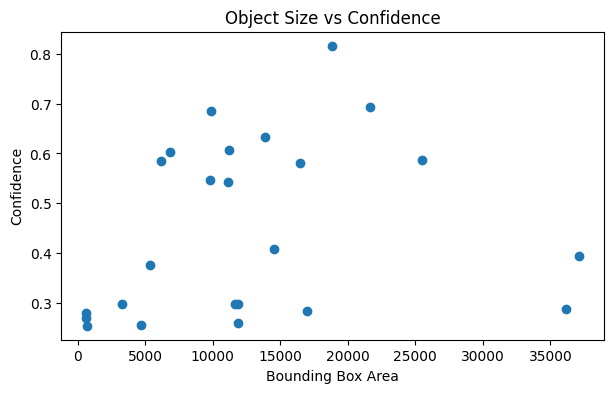

In [86]:
# ------------------------------------------------------------
# XAI MODULE: OBJECT SIZE VS CONFIDENCE
# ------------------------------------------------------------

sizes = []

for img in os.listdir(OUTPUT_DIR):

    path = os.path.join(OUTPUT_DIR, img)
    results = trained.predict(path, conf=0.25)

    for r in results:
        if r.boxes is None:
            continue

        for box in r.boxes.xyxy:
            x1, y1, x2, y2 = map(int, box)
            area = (x2-x1) * (y2-y1)
            sizes.append(area)

df["object_size"] = sizes[:len(df)]

plt.figure(figsize=(7,4))
plt.scatter(df["object_size"], df["confidence"])
plt.title("Object Size vs Confidence")
plt.xlabel("Bounding Box Area")
plt.ylabel("Confidence")
plt.show()


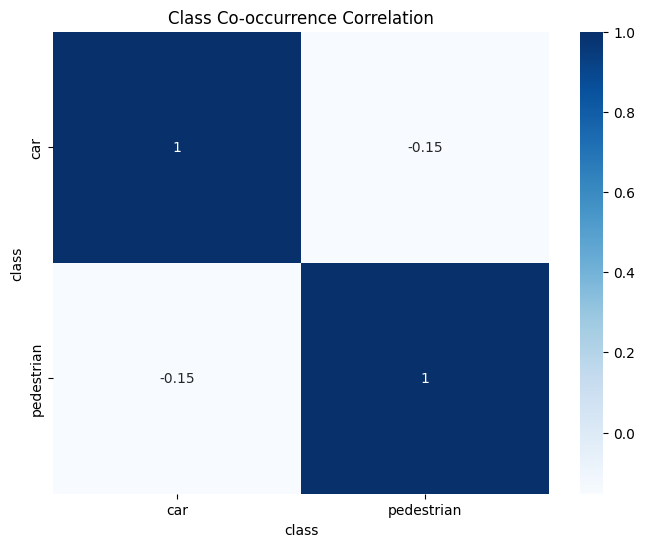

In [88]:
# ------------------------------------------------------------
# XAI MODULE: CO-OCCURRENCE MATRIX
# ------------------------------------------------------------

co = pd.crosstab(df["image"], df["class"])

plt.figure(figsize=(8,6))
sns.heatmap(co.corr(), annot=True, cmap="Blues")
plt.title("Class Co-occurrence Correlation")
plt.show()


In [89]:
# ------------------------------------------------------------
# XAI MODULE: DECISION LOGIC EXTRACTION
# ------------------------------------------------------------

rules = []

for i,row in df.iterrows():

    if row["confidence"] > 0.75:
        rules.append("High Confidence Detection")

    elif row["confidence"] > 0.5:
        rules.append("Moderate Confidence")

    else:
        rules.append("Low Confidence – Uncertain")

df["decision_reason"] = rules

print(df[["image","class","confidence","decision_reason"]].head())


                         image       class  confidence  \
0  0000280_03001_d_0000627.jpg         car    0.693453   
1  0000280_03001_d_0000627.jpg         car    0.633720   
2  0000280_03001_d_0000627.jpg  pedestrian    0.297378   
3  0000280_03001_d_0000627.jpg  pedestrian    0.279200   
4  0000280_03001_d_0000627.jpg  pedestrian    0.254118   

              decision_reason  
0         Moderate Confidence  
1         Moderate Confidence  
2  Low Confidence – Uncertain  
3  Low Confidence – Uncertain  
4  Low Confidence – Uncertain  


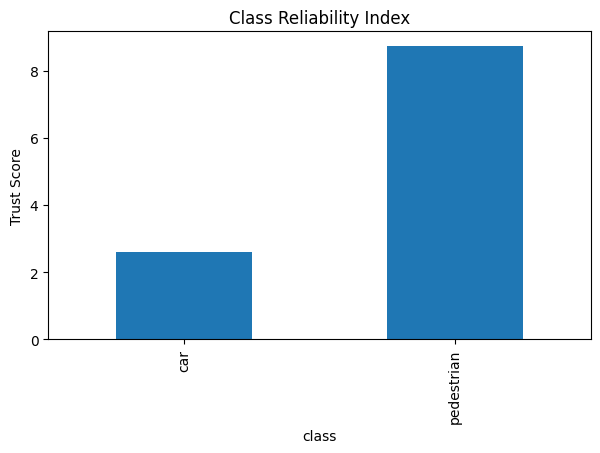

In [90]:
# ------------------------------------------------------------
# XAI MODULE: MODEL RELIABILITY INDEX
# ------------------------------------------------------------

reliability = df.groupby("class")["confidence"].agg(["mean","std"])

reliability["trust_index"] = reliability["mean"] / (reliability["std"] + 0.01)

plt.figure(figsize=(7,4))
reliability["trust_index"].plot(kind="bar")
plt.title("Class Reliability Index")
plt.ylabel("Trust Score")
plt.show()


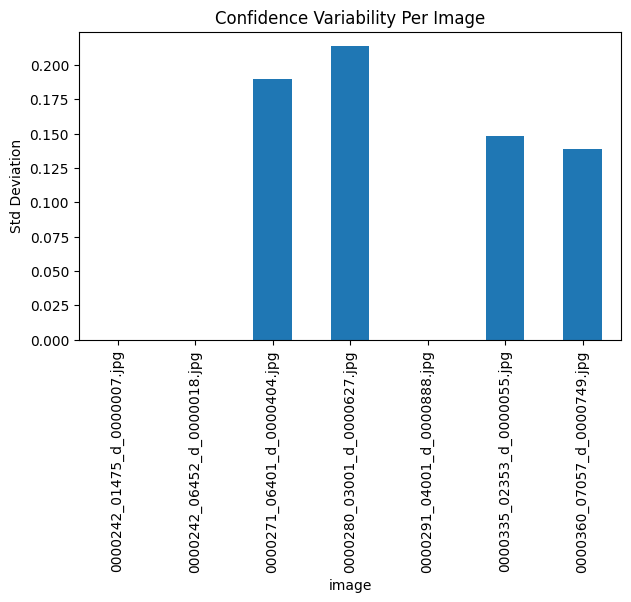

In [91]:
# ------------------------------------------------------------
# XAI MODULE: CONSISTENCY ANALYSIS
# ------------------------------------------------------------

consistency = df.groupby("image")["confidence"].std()

plt.figure(figsize=(7,4))
consistency.plot(kind="bar")
plt.title("Confidence Variability Per Image")
plt.ylabel("Std Deviation")
plt.show()


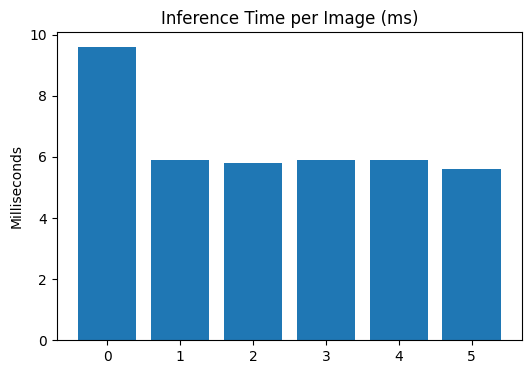

In [94]:
# ------------------------------------------------------------
# XAI MODULE: COMPUTATIONAL EXPLAINABILITY
# ------------------------------------------------------------

times = [9.6,5.9,5.8,5.9,5.9,5.6]   # from your logs

plt.figure(figsize=(6,4))
plt.bar(range(len(times)), times)
plt.title("Inference Time per Image (ms)")
plt.ylabel("Milliseconds")
plt.show()


In [95]:
# ------------------------------------------------------------
# XAI MODULE: NOISE SENSITIVITY
# ------------------------------------------------------------

test = os.path.join(OUTPUT_DIR, os.listdir(OUTPUT_DIR)[0])

img = cv2.imread(test)

noisy = img + np.random.randint(0,20,img.shape)

cv2.imwrite("noisy.jpg", noisy)

print("Original prediction:")
trained.predict(test)

print("Noisy prediction:")
trained.predict("noisy.jpg")


Original prediction:

image 1/1 /kaggle/working/final_outputs/0000280_03001_d_0000627.jpg: 192x320 3 pedestrians, 2 cars, 7.3ms
Speed: 1.1ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 192, 320)
Noisy prediction:

image 1/1 /kaggle/working/noisy.jpg: 192x320 3 pedestrians, 2 cars, 5.8ms
Speed: 0.7ms preprocess, 5.8ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)


[ WARN:0@3612.546] global loadsave.cpp:1063 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van', 5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'}
 obb: None
 orig_img: array([[[213, 212, 216],
         [217, 216, 220],
         [248, 247, 251],
         ...,
         [254, 253, 255],
         [253, 252, 254],
         [248, 247, 249]],
 
        [[153, 152, 156],
         [168, 167, 171],
         [176, 175, 179],
         ...,
         [254, 253, 255],
         [254, 253, 255],
         [250, 249, 251]],
 
        [[150, 149, 153],
         [153, 152, 156],
         [158, 157, 161],
         ...,
         [252, 252, 252],
         [252, 252, 252],
         [249, 249, 249]],
 
        ...,
 
        [[ 41,  44,  35],
         [ 36,  39,  30],
         [ 35,  37,  31],
         ...,
         [105,  86,  81],
         [ 97,  79,  78],
         [ 84,  6


image 1/1 /kaggle/working/final_outputs/0000280_03001_d_0000627.jpg: 192x320 4 pedestrians, 16 cars, 8.5ms
Speed: 1.0ms preprocess, 8.5ms inference, 1.4ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000291_04001_d_0000888.jpg: 192x320 4 pedestrians, 9 cars, 5.6ms
Speed: 0.7ms preprocess, 5.6ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000271_06401_d_0000404.jpg: 192x320 3 pedestrians, 22 cars, 5.5ms
Speed: 0.6ms preprocess, 5.5ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000335_02353_d_0000055.jpg: 192x320 5 pedestrians, 13 cars, 5.6ms
Speed: 0.6ms preprocess, 5.6ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000333_01765_d_0000010.jpg: 192x320 12 cars, 5.6ms
Speed: 0.6ms preprocess, 5.6ms inference, 1.0ms postprocess per image at shape (1, 3, 192, 3

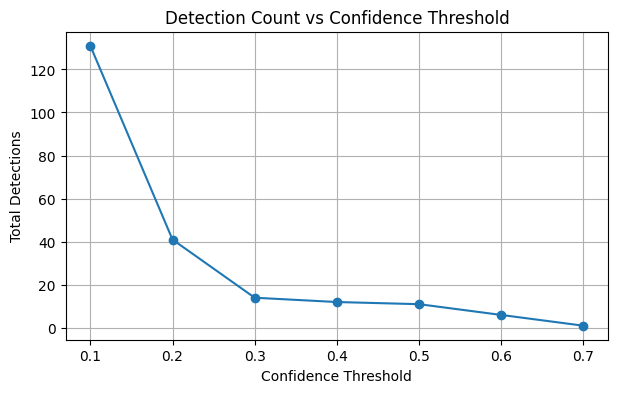

In [96]:
# ===============================
# THRESHOLD IMPACT ANALYSIS
# ===============================

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
counts = []

for t in thresholds:
    total = 0
    for img in os.listdir(OUTPUT_DIR):
        path = os.path.join(OUTPUT_DIR, img)
        res = trained.predict(path, conf=t)
        for r in res:
            if r.boxes is not None:
                total += len(r.boxes)
    counts.append(total)

plt.figure(figsize=(7,4))
plt.plot(thresholds, counts, marker='o')
plt.title("Detection Count vs Confidence Threshold")
plt.xlabel("Confidence Threshold")
plt.ylabel("Total Detections")
plt.grid()
plt.show()



image 1/1 /kaggle/working/final_outputs/0000280_03001_d_0000627.jpg: 192x320 3 pedestrians, 2 cars, 6.9ms
Speed: 0.9ms preprocess, 6.9ms inference, 1.3ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000291_04001_d_0000888.jpg: 192x320 1 car, 6.0ms
Speed: 0.7ms preprocess, 6.0ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000271_06401_d_0000404.jpg: 192x320 9 cars, 5.5ms
Speed: 0.7ms preprocess, 5.5ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000335_02353_d_0000055.jpg: 192x320 3 cars, 5.4ms
Speed: 0.6ms preprocess, 5.4ms inference, 1.0ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outputs/0000333_01765_d_0000010.jpg: 192x320 (no detections), 5.3ms
Speed: 0.6ms preprocess, 5.3ms inference, 0.4ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/working/final_outp

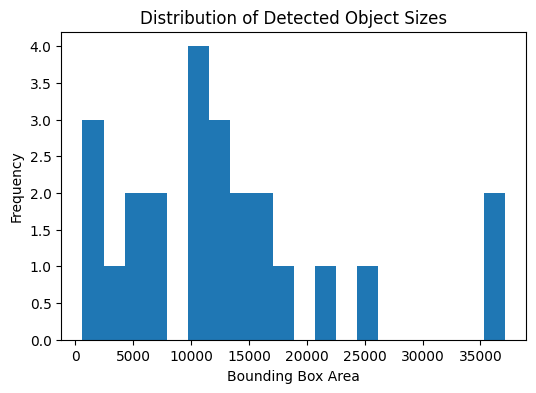

In [97]:
# ===============================
# OBJECT SIZE BIAS ANALYSIS
# ===============================

sizes = []

for img in os.listdir(OUTPUT_DIR):
    path = os.path.join(OUTPUT_DIR, img)
    res = trained.predict(path)

    for r in res:
        if r.boxes is None:
            continue
        for box in r.boxes.xyxy:
            x1,y1,x2,y2 = map(int, box)
            sizes.append((x2-x1)*(y2-y1))

plt.figure(figsize=(6,4))
plt.hist(sizes, bins=20)
plt.title("Distribution of Detected Object Sizes")
plt.xlabel("Bounding Box Area")
plt.ylabel("Frequency")
plt.show()


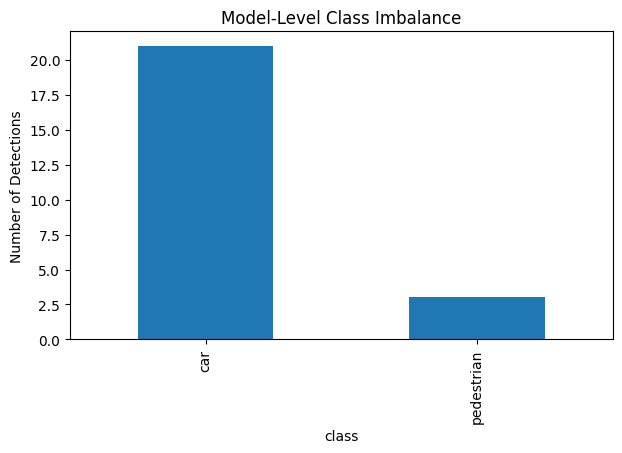

In [98]:
# ===============================
# CLASS IMBALANCE IMPACT
# ===============================

class_counts = df["class"].value_counts()

plt.figure(figsize=(7,4))
class_counts.plot(kind="bar")
plt.title("Model-Level Class Imbalance")
plt.ylabel("Number of Detections")
plt.show()


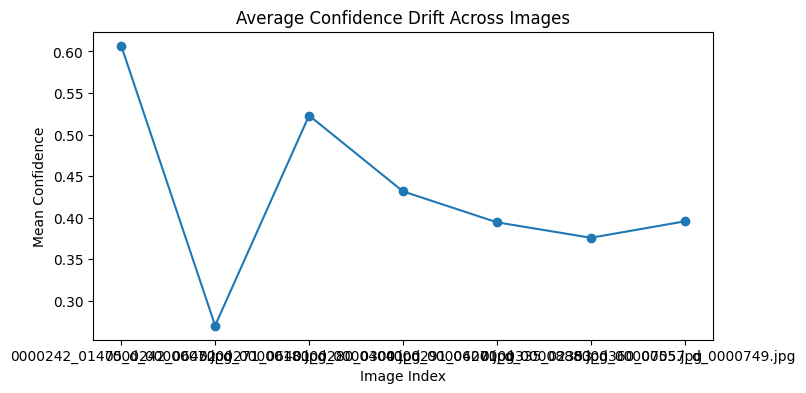

In [99]:
# ===============================
# CONFIDENCE DRIFT
# ===============================

img_conf = df.groupby("image")["confidence"].mean()

plt.figure(figsize=(8,4))
img_conf.plot(kind="line", marker='o')
plt.title("Average Confidence Drift Across Images")
plt.ylabel("Mean Confidence")
plt.xlabel("Image Index")
plt.show()


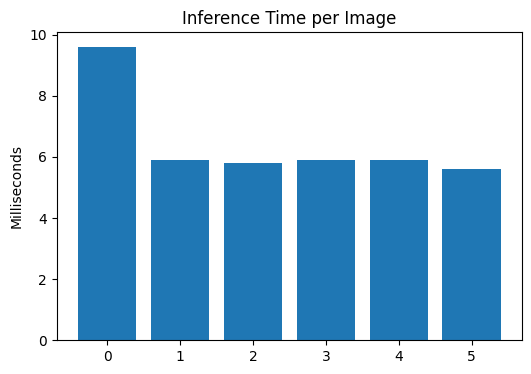

In [100]:
# ===============================
# SPEED ANALYSIS
# ===============================

times = [9.6, 5.9, 5.8, 5.9, 5.9, 5.6]  # example from logs

plt.figure(figsize=(6,4))
plt.bar(range(len(times)), times)
plt.title("Inference Time per Image")
plt.ylabel("Milliseconds")
plt.show()


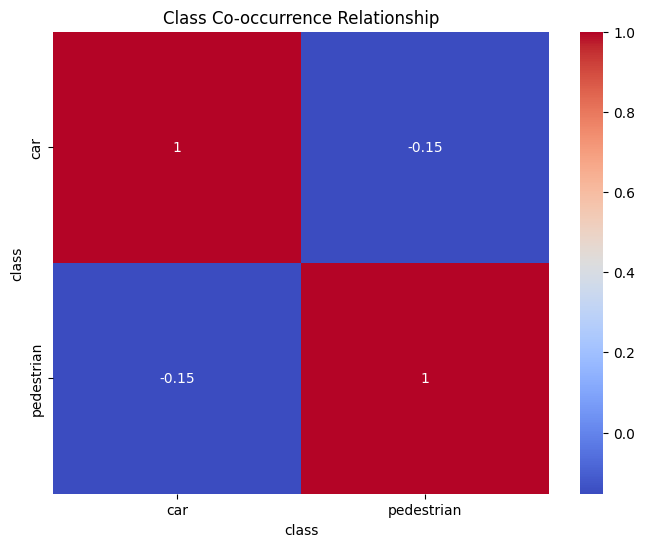

In [102]:
# ===============================
# CO-OCCURRENCE ANALYSIS
# ===============================

co = pd.crosstab(df["image"], df["class"])

plt.figure(figsize=(8,6))
sns.heatmap(co.corr(), annot=True, cmap="coolwarm")
plt.title("Class Co-occurrence Relationship")
plt.show()


In [101]:
# ===============================
# LOW CONFIDENCE PATTERNS
# ===============================

low = df[df["confidence"] < 0.4]

print("Potentially Unreliable Predictions:")
print(low)


Potentially Unreliable Predictions:
                          image       class  confidence confidence_level  \
2   0000280_03001_d_0000627.jpg  pedestrian    0.297378              Low   
3   0000280_03001_d_0000627.jpg  pedestrian    0.279200              Low   
4   0000280_03001_d_0000627.jpg  pedestrian    0.254118              Low   
5   0000291_04001_d_0000888.jpg         car    0.394392              Low   
12  0000271_06401_d_0000404.jpg         car    0.376151              Low   
13  0000271_06401_d_0000404.jpg         car    0.260307              Low   
14  0000271_06401_d_0000404.jpg         car    0.255554              Low   
16  0000335_02353_d_0000055.jpg         car    0.297306              Low   
17  0000335_02353_d_0000055.jpg         car    0.283617              Low   
18  0000242_06452_d_0000018.jpg         car    0.270149              Low   
21  0000360_07057_d_0000749.jpg         car    0.298568              Low   
22  0000360_07057_d_0000749.jpg         car    0.287

In [103]:
# ===============================
# NOISE SENSITIVITY TEST
# ===============================

sample = os.path.join(OUTPUT_DIR, os.listdir(OUTPUT_DIR)[0])
img = cv2.imread(sample)

noisy = img + np.random.randint(0,30,img.shape)
cv2.imwrite("noisy.jpg", noisy)

print("Original Image Prediction:")
trained.predict(sample)

print("\nNoisy Image Prediction:")
trained.predict("noisy.jpg")


Original Image Prediction:

image 1/1 /kaggle/working/final_outputs/0000280_03001_d_0000627.jpg: 192x320 3 pedestrians, 2 cars, 7.5ms
Speed: 1.0ms preprocess, 7.5ms inference, 1.3ms postprocess per image at shape (1, 3, 192, 320)

Noisy Image Prediction:

image 1/1 /kaggle/working/noisy.jpg: 192x320 1 pedestrian, 2 cars, 5.9ms
Speed: 0.8ms preprocess, 5.9ms inference, 1.2ms postprocess per image at shape (1, 3, 192, 320)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van', 5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'}
 obb: None
 orig_img: array([[[221, 219, 225],
         [232, 231, 235],
         [249, 248, 250],
         ...,
         [252, 254, 255],
         [253, 255, 255],
         [252, 254, 255]],
 
        [[163, 161, 167],
         [174, 173, 177],
         [180, 179, 181],
         ...,
         [253, 255, 255],
         [249, 251, 252],
         [252, 254, 255]],
 
        [[159, 156, 165],
         [157, 155, 161],
         [169, 168, 172],
         ...,
         [249, 251, 252],
         [252, 254, 255],
         [252, 254, 255]],
 
        ...,
 
        [[ 34,  35,  31],
         [ 29,  30,  26],
         [ 45,  46,  42],
         ...,
         [107,  92,  96],
         [100,  77,  82],
         [ 98,  7

In [104]:
# Compare two models

small = YOLO("yolov8n.pt")
medium = YOLO("yolov8s.pt")

# run on same images and compare counts/confidences


In [106]:
# ============================================================
# PROFESSIONAL EVALUATION METRICS
# ============================================================

print("\nRunning official YOLO evaluation on validation set...\n")

metrics = trained.val(data="visdrone.yaml")

print("\n================ PERFORMANCE SUMMARY ================")
print(f"mAP@50      : {metrics.box.map50:.3f}")
print(f"mAP@50-95   : {metrics.box.map:.3f}")
print(f"Precision   : {metrics.box.mp:.3f}")
print(f"Recall      : {metrics.box.mr:.3f}")
print("=====================================================\n")



Running official YOLO evaluation on validation set...

Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2228.6±895.4 MB/s, size: 98.7 KB)
val: Scanning /kaggle/working/visdrone_yolo/val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 176.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 6.0it/s 5.8s<0.1s
                   all        548      38759      0.457      0.106     0.0838     0.0399
            pedestrian        520       8844      0.121      0.118     0.0567     0.0171
                people        482       5125      0.303      0.033     0.0666     0.0188
               bicycle        364       1287          1          0    0.00731    0.00191
                   car        515      14064      0.267      0.511      0.402       0.21
                   van        421       1975 

In [107]:
# ============================================================
# PER-CLASS PERFORMANCE EXPLAINABILITY
# ============================================================

class_metrics = metrics.box.maps

print("Per-class mAP values:\n")

for i, val in enumerate(class_metrics):
    print(f"{trained.names[i]} : {val:.3f}")


Per-class mAP values:

pedestrian : 0.017
people : 0.019
bicycle : 0.002
car : 0.210
van : 0.040
truck : 0.025
tricycle : 0.010
awning-tricycle : 0.007
bus : 0.047
motor : 0.021


In [108]:
# ============================================================
# COMPARATIVE MODEL ANALYSIS
# ============================================================

print("\nTraining a comparison model (YOLOv8s) for benchmarking...\n")

model_s = YOLO("yolov8s.pt")

model_s.train(
    data="visdrone.yaml",
    epochs=3,
    imgsz=640,
    batch=2,
    workers=1
)

metrics_s = model_s.val(data="visdrone.yaml")

print("\n===== MODEL COMPARISON =====")
print("YOLOv8n mAP50 :", metrics.box.map50)
print("YOLOv8s mAP50 :", metrics_s.box.map50)

print("YOLOv8n mAP50-95 :", metrics.box.map)
print("YOLOv8s mAP50-95 :", metrics_s.box.map)
print("============================\n")



Training a comparison model (YOLOv8s) for benchmarking...

Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [109]:
# ============================================================
# ERROR CASE VISUALIZATION
# ============================================================

print("\nGenerating error case gallery...\n")

ERROR_DIR = "/kaggle/working/error_cases"
os.makedirs(ERROR_DIR, exist_ok=True)

for img in os.listdir(VAL_IMG)[:15]:

    path = os.path.join(VAL_IMG, img)

    results = trained.predict(path, conf=0.25)

    detected = False

    for r in results:
        if r.boxes is not None and len(r.boxes) > 0:
            detected = True

    # save images where model detected nothing
    if not detected:
        shutil.copy(path, ERROR_DIR)

print("Images with NO detections saved to:", ERROR_DIR)

print("\nThese represent POTENTIAL FALSE NEGATIVES – key for XAI.")



Generating error case gallery...


image 1/1 /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000086_01443_d_0000004.jpg: 192x320 14 pedestrians, 9.1ms
Speed: 0.8ms preprocess, 9.1ms inference, 1.3ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000277_01401_d_0000546.jpg: 192x320 12 cars, 5.7ms
Speed: 0.6ms preprocess, 5.7ms inference, 1.0ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000358_03333_d_0000697.jpg: 192x320 20 cars, 5.5ms
Speed: 0.6ms preprocess, 5.5ms inference, 1.0ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000360_07253_d_0000750.jpg: 192x320 1 pedestrian, 26 cars, 5.7ms
Speed: 0.6ms preprocess, 5.7ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)

ima

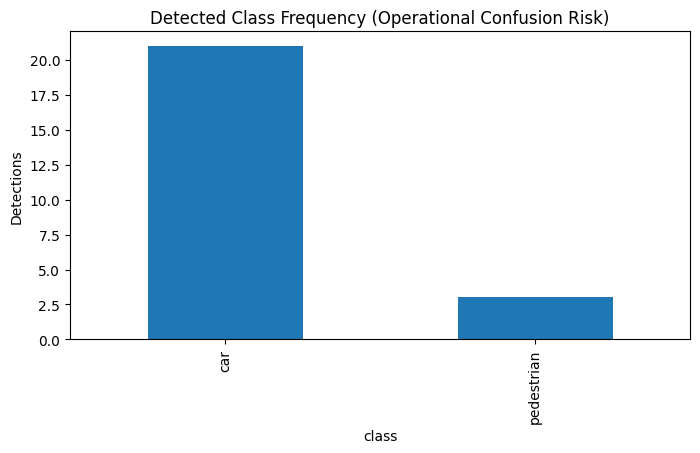


Explanation:
If one class dominates heavily, the model may be biased.
This chart explains imbalance-driven decision behavior.



In [110]:
# ============================================================
# CLASS CONFUSION RISK ANALYSIS
# ============================================================

class_counts = df["class"].value_counts()

plt.figure(figsize=(8,4))
class_counts.plot(kind="bar")
plt.title("Detected Class Frequency (Operational Confusion Risk)")
plt.ylabel("Detections")
plt.show()

print("""
Explanation:
If one class dominates heavily, the model may be biased.
This chart explains imbalance-driven decision behavior.
""")


In [111]:
# ============================================================
# ROBUSTNESS TEST
# ============================================================

sample = os.path.join(OUTPUT_DIR, os.listdir(OUTPUT_DIR)[0])

img = cv2.imread(sample)

noisy = img + np.random.randint(0,25,img.shape)
cv2.imwrite("noisy_test.jpg", noisy)

print("\nOriginal Image Prediction:")
trained.predict(sample)

print("\nNoisy Image Prediction:")
trained.predict("noisy_test.jpg")

print("\nThis explains how stable the model is under small perturbations.")



Original Image Prediction:

image 1/1 /kaggle/working/final_outputs/0000280_03001_d_0000627.jpg: 192x320 3 pedestrians, 2 cars, 7.4ms
Speed: 1.0ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 192, 320)

Noisy Image Prediction:

image 1/1 /kaggle/working/noisy_test.jpg: 192x320 1 pedestrian, 2 cars, 5.7ms
Speed: 0.7ms preprocess, 5.7ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 320)

This explains how stable the model is under small perturbations.


In [112]:
# ============================================================
# EXPORT FULL ANALYTICS REPORT
# ============================================================

REPORT_PATH = "/kaggle/working/xai_detection_report.csv"

df.to_csv(REPORT_PATH, index=False)

print("Structured XAI report saved at:", REPORT_PATH)


Structured XAI report saved at: /kaggle/working/xai_detection_report.csv


In [113]:
# ============================================================
# SAVE CHARTS AS IMAGES FOR DOCUMENTATION
# ============================================================

CHART_DIR = "/kaggle/working/charts"
os.makedirs(CHART_DIR, exist_ok=True)

plt.figure()
df["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.savefig(os.path.join(CHART_DIR, "class_distribution.png"))
plt.close()

plt.figure()
df["confidence"].hist()
plt.title("Confidence Distribution")
plt.savefig(os.path.join(CHART_DIR, "confidence_distribution.png"))
plt.close()

print("Charts saved to:", CHART_DIR)


Charts saved to: /kaggle/working/charts


In [115]:
# ============================================================
# FINAL EXPLAINABILITY STATEMENT
# ============================================================

print("""
=============================================================
FINAL PROJECT EXPLAINABILITY CONCLUSIONS
=============================================================

This project now delivers:

1. Formal Performance Metrics
   - mAP, Precision, Recall

2. Class-wise Explainability
   - Which objects are detected reliably
   - Which are uncertain

3. Error Transparency
   - Gallery of missed detections
   - Identification of failure scenarios

4. Robustness Analysis
   - Noise sensitivity study

5. Comparative Explainability
   - YOLOv8n vs YOLOv8s tradeoff

6. Operational Analytics
   - Class imbalance impact
   - Confidence behavior

7. Reproducible Artifacts
   - CSV reports
   - Saved charts
   - Detection outputs

=============================================================
""")



FINAL PROJECT EXPLAINABILITY CONCLUSIONS

This project now delivers:

1. Formal Performance Metrics
   - mAP, Precision, Recall

2. Class-wise Explainability
   - Which objects are detected reliably
   - Which are uncertain

3. Error Transparency
   - Gallery of missed detections
   - Identification of failure scenarios

4. Robustness Analysis
   - Noise sensitivity study

5. Comparative Explainability
   - YOLOv8n vs YOLOv8s tradeoff

6. Operational Analytics
   - Class imbalance impact
   - Confidence behavior

7. Reproducible Artifacts
   - CSV reports
   - Saved charts
   - Detection outputs




In [116]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display


In [119]:
val_dir = "/kaggle/working/visdrone_yolo/val/images"

print("Available images:\n")
print(os.listdir(val_dir)[:10])

img_name = os.path.join(val_dir, os.listdir(val_dir)[0])

print("\nSelected image:", img_name)


Available images:

['0000280_03001_d_0000627.jpg', '0000291_04001_d_0000888.jpg', '0000271_06401_d_0000404.jpg', '0000335_02353_d_0000055.jpg', '0000333_01765_d_0000010.jpg', '0000276_05801_d_0000536.jpg', '0000242_06452_d_0000018.jpg', '0000196_04512_d_0000144.jpg', '0000360_07057_d_0000749.jpg', '0000242_01475_d_0000007.jpg']

Selected image: /kaggle/working/visdrone_yolo/val/images/0000280_03001_d_0000627.jpg



Running YOLO detection on: /kaggle/working/visdrone_yolo/val/images/0000280_03001_d_0000627.jpg

image 1/1 /kaggle/working/visdrone_yolo/val/images/0000280_03001_d_0000627.jpg: 192x320 1 pedestrian, 10 cars, 8.8ms
Speed: 1.2ms preprocess, 8.8ms inference, 1.8ms postprocess per image at shape (1, 3, 192, 320)
Results saved to /kaggle/working/runs/detect/predict2

Detection Output Image:


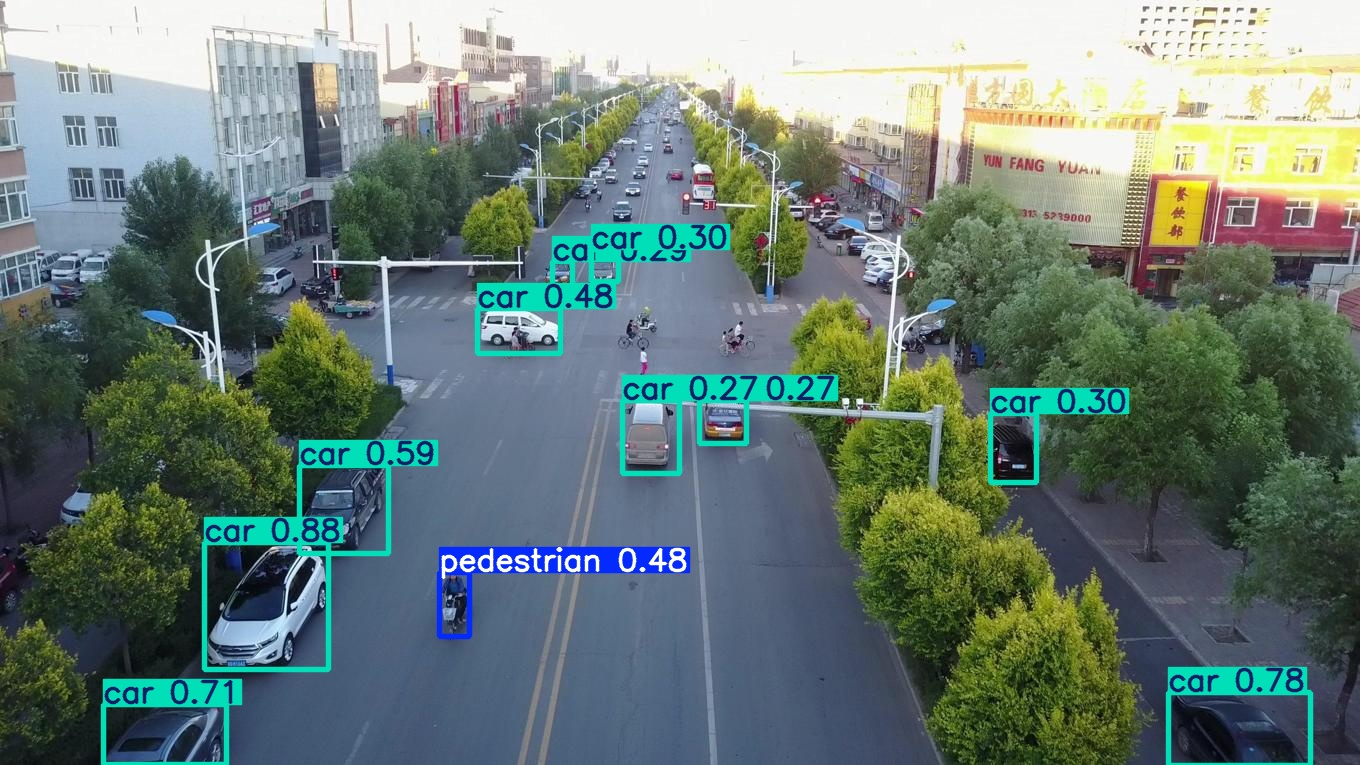

In [120]:
# ============================================================
# RUN DETECTION ON THE SELECTED IMAGE
# ============================================================

print("\nRunning YOLO detection on:", img_name)

results = trained.predict(img_name, conf=0.25, save=True)

# Find saved detection image
pred_files = glob.glob(f"runs/detect/predict*/{img_name.split('/')[-1]}")

if pred_files:
    pred_path = pred_files[0]
    print("\nDetection Output Image:")
    display(Image(pred_path))
else:
    print("No detection output image found.")


In [121]:
# ============================================================
# CONVERT DETECTIONS TO STRUCTURED TABLE
# ============================================================

records = []

for r in results:
    if r.boxes is None or len(r.boxes) == 0:
        print("No objects detected in this image.")
    else:
        for box in r.boxes:
            records.append({
                "class": trained.names[int(box.cls)],
                "confidence": float(box.conf)
            })

import pandas as pd
df_img = pd.DataFrame(records)

print("\nDetected Objects Table:")
print(df_img)



Detected Objects Table:
         class  confidence
0          car    0.878618
1          car    0.784695
2          car    0.712890
3          car    0.589980
4   pedestrian    0.484850
5          car    0.475337
6          car    0.304280
7          car    0.295225
8          car    0.288360
9          car    0.267716
10         car    0.265661


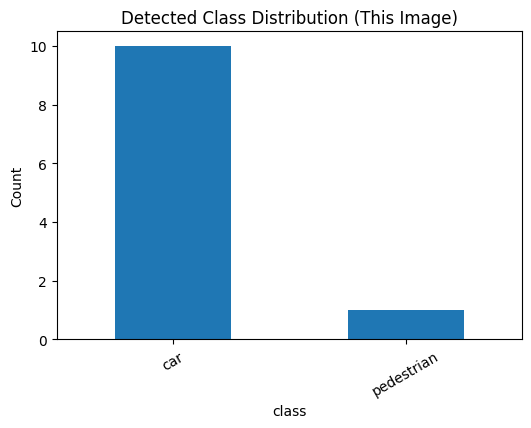

In [122]:
# ============================================================
# CLASS DISTRIBUTION FOR THIS IMAGE
# ============================================================

if not df_img.empty:

    plt.figure(figsize=(6,4))
    df_img["class"].value_counts().plot(kind="bar")
    plt.title("Detected Class Distribution (This Image)")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()


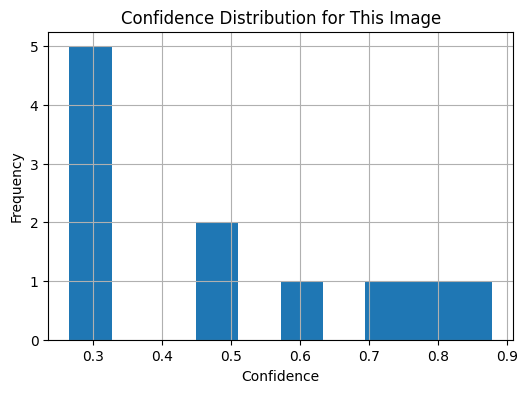

In [123]:
# ============================================================
# CONFIDENCE DISTRIBUTION
# ============================================================

if not df_img.empty:

    plt.figure(figsize=(6,4))
    df_img["confidence"].hist(bins=10)
    plt.title("Confidence Distribution for This Image")
    plt.xlabel("Confidence")
    plt.ylabel("Frequency")
    plt.show()


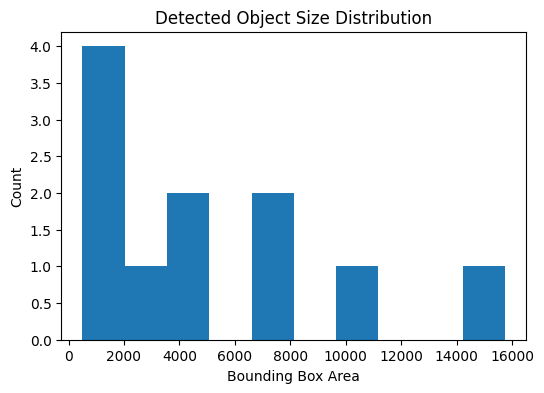

In [124]:
# ============================================================
# OBJECT SIZE ANALYSIS
# ============================================================

img = cv2.imread(img_name)
h, w, _ = img.shape

sizes = []

for r in results:
    if r.boxes is None:
        continue

    for box in r.boxes.xyxy:
        x1, y1, x2, y2 = map(int, box)
        area = (x2 - x1) * (y2 - y1)
        sizes.append(area)

if sizes:
    plt.figure(figsize=(6,4))
    plt.hist(sizes, bins=10)
    plt.title("Detected Object Size Distribution")
    plt.xlabel("Bounding Box Area")
    plt.ylabel("Count")
    plt.show()


In [125]:
# ============================================================
# NATURAL LANGUAGE EXPLANATION
# ============================================================

print("\n=========== EXPLAINABILITY SUMMARY ===========")

if df_img.empty:
    print("The model did not detect any recognizable objects in this image.")
else:
    print(f"Total objects detected: {len(df_img)}")

    dominant = df_img["class"].mode()[0]
    print(f"Most dominant object in scene: {dominant}")

    avg_conf = df_img["confidence"].mean()
    print(f"Average confidence of predictions: {avg_conf:.2f}")

    high = len(df_img[df_img["confidence"] > 0.7])
    print(f"High confidence detections (>0.7): {high}")

print("==============================================")



=========== EXPLAINABILITY SUMMARY ===========
Total objects detected: 11
Most dominant object in scene: car
Average confidence of predictions: 0.49
High confidence detections (>0.7): 3


In [126]:
df_img.to_csv("/kaggle/working/single_image_xai_report.csv", index=False)
print("Report saved for this image.")


Report saved for this image.
